# DBSCAN + UMAP Trajectory Analysis

This notebook loads one prepared trajectory-characteristics export, maps those rows back to the run's joined trajectory-metrics CSV, derives DBSCAN hyperparameters from the k-distance heuristic, projects the standardized characteristics into two dimensions with UMAP, and saves cluster and metric-colored visualizations.<br>
**Workflow summary:** bootstrap local imports, resolve one run spec, load the prepared and joined run-scoped data, validate row alignment, standardize trajectory characteristics, create a k-distance plot to set DBSCAN parameters, fit DBSCAN and UMAP, visualize the embedding by cluster and fixed metric views, then export plots and the enriched analysis table.


## 1. Notebook Bootstrap
**Purpose:** Ensure the notebook can import local helper modules regardless of launch directory.<br>
**Inputs:** current working directory and repository `src/` layout.<br>
**Outputs:** `src/` added to `sys.path` before any local imports run.<br>
**How to Verify:** the bootstrap cell should execute without error and later local imports should succeed without manual path edits.


In [16]:
# Ensure the notebook can import local helper modules even when it is launched
# from a nested working directory inside the repository.
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    src_dir = candidate / 'src'
    if (src_dir / 'data_modelling').exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break
else:
    raise RuntimeError('Could not locate repo src/ directory for notebook imports.')


## 2. Imports and Configuration
**Purpose:** Load the clustering/plotting dependencies and define the explicit run specification for this analysis.<br>
**Inputs:** local helper modules, plotting libraries, clustering libraries, and notebook-local run settings.<br>
**Outputs:** imported libraries, resolved run spec, fixed metric list, and output directories ready for saved artifacts.<br>
**How to Verify:** confirm the printed run metadata, resolved input paths, and output directories before data loading starts.


In [17]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import umap

from data_modelling.prepared_data import load_prepared_data, prepare_single_target_model_data

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RUN_SPEC = {
    'run_name': 'nusc_mini_debug_tpp-11_Mar_2026_15_29_02',
    'prepared_target': 'ml_ade',
    'eval_csv_name': 'eval_epoch_5.csv',
    'dbscan_min_samples': None,
    'dbscan_border_object_rank': 4,
    'umap_n_neighbors': 15,
    'umap_min_dist': 0.1,
    'random_state': 42,
}

METRIC_COLS = [
    'ml_ade',
    'ml_fde',
    'min_ade_5',
    'nll_mean',
    'nll_final',
]

run_name = RUN_SPEC['run_name']
prepared_target = RUN_SPEC['prepared_target']
eval_csv_name = RUN_SPEC['eval_csv_name']

PREPARED_DATA_PATH = Path('../../results/interpretable_model/prepared_data') / run_name / f'prepared_data_{prepared_target}.csv'
JOINED_METRICS_PATH = Path('../../results/trajectory_prediction/trajectory_metrics_joined') / run_name / eval_csv_name

RESULTS_ROOT = Path('../../results/interpretable_model/dbscan_umap') / run_name
PLOTS_DIR = RESULTS_ROOT / 'plots'
TABLES_DIR = RESULTS_ROOT / 'tables'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Run spec: {RUN_SPEC}')
print('DBSCAN heuristic: min_samples defaults to 2 * d - 1 when RUN_SPEC["dbscan_min_samples"] is None.')
print('DBSCAN heuristic: eps is set to the sorted MinPts-distance at RUN_SPEC["dbscan_border_object_rank"].')
print(f'PREPARED_DATA_PATH: {PREPARED_DATA_PATH.resolve()}')
print(f'JOINED_METRICS_PATH: {JOINED_METRICS_PATH.resolve()}')
print(f'RESULTS_ROOT: {RESULTS_ROOT.resolve()}')


Run spec: {'run_name': 'nusc_mini_debug_tpp-11_Mar_2026_15_29_02', 'prepared_target': 'ml_ade', 'eval_csv_name': 'eval_epoch_5.csv', 'dbscan_min_samples': None, 'dbscan_border_object_rank': 4, 'umap_n_neighbors': 15, 'umap_min_dist': 0.1, 'random_state': 42}
DBSCAN heuristic: min_samples defaults to 2 * d - 1 when RUN_SPEC["dbscan_min_samples"] is None.
DBSCAN heuristic: eps is set to the sorted MinPts-distance at RUN_SPEC["dbscan_border_object_rank"].
PREPARED_DATA_PATH: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/prepared_data/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/prepared_data_ml_ade.csv
JOINED_METRICS_PATH: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/trajectory_prediction/trajectory_metrics_joined/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/eval_epoch_5.csv
RESULTS_ROOT: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/dbscan_umap/nusc_mini_debug_tpp-11_Mar_2026_15_29_02


## 3. Load Prepared Data and Resolve Clustering Features
**Purpose:** Load the prepared trajectory-characteristics table and freeze the feature contract used for clustering and join-back alignment.<br>
**Inputs:** prepared-data CSV path and the shared prepared-data helpers.<br>
**Outputs:** prepared dataframe, resolved target column, clustering feature list, and one filtered modelling frame without missing values.<br>
**How to Verify:** confirm the resolved `target_col`, clustering feature count, and final modelling row count before loading the joined metrics CSV.


In [18]:
prepared_df = load_prepared_data(
    PREPARED_DATA_PATH,
    display_fn=display,
    include_missing_summary=True,
    include_dtype_summary=True,
)

prepared = prepare_single_target_model_data(
    prepared_df,
    target_col=None,
    default_target=prepared_target,
)

target_col = prepared['target_col']
feature_cols = prepared['feature_cols']
model_df = prepared['model_df'].copy()
X = prepared['X'].copy()

print(f'Resolved target column: {target_col}')
print(f'Clustering feature count: {len(feature_cols)}')
print(f'Clustering features: {feature_cols}')
print(f'Rows available for clustering: {len(model_df)}')


Dataset shape: (451, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'mean_jerk', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,mean_jerk,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.230403,0.116722,0.056417,0.490805,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.649643
1,0.218477,0.063105,0.007725,0.490449,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.140704
2,0.383437,0.099171,0.031384,0.401269,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,40.892780,0.027456,0.012630,0.388765
3,1.483624,0.190256,0.051802,0.879107,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,28.355738,0.013004,0.005689,0.821990
4,0.218477,0.064457,0.010995,0.483671,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,28.309616,0.014190,0.005676,0.159340



Missing values per column:


,missing_count
max_speed,0
std_speed,0
mean_acceleration,0
mean_jerk,0
heading_change,0
has_collision,0
min_neighbor_distance,0
scene_num_agents,0
scene_bbox_area,0
scene_bbox_width,0



Column dtypes:


,dtype
max_speed,float64
std_speed,float64
mean_acceleration,float64
mean_jerk,float64
heading_change,float64
has_collision,float64
min_neighbor_distance,float64
scene_num_agents,float64
scene_bbox_area,float64
scene_bbox_width,float64


Resolved target column: ml_ade_log
Clustering feature count: 13
Clustering features: ['max_speed', 'std_speed', 'mean_acceleration', 'mean_jerk', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE']
Rows available for clustering: 451


## 4. Load Joined Metrics and Validate Row Alignment
**Purpose:** Reattach the raw trajectory-metric columns needed for UMAP coloring without changing the clustering feature contract.<br>
**Inputs:** filtered prepared rows, run-scoped joined metrics CSV, and the clustering feature columns.<br>
**Outputs:** one merged analysis dataframe with prepared rows, selected metric columns, and verified one-to-one alignment.<br>
**How to Verify:** confirm both frames are unique on the merge key, the merged row count matches the prepared row count exactly, and any missing fixed metrics are only warned about.


In [19]:
joined_df = pd.read_csv(JOINED_METRICS_PATH)
print(f'Joined metrics shape: {joined_df.shape}')

missing_feature_cols = [col for col in feature_cols if col not in joined_df.columns]
if missing_feature_cols:
    raise KeyError(
        'Joined metrics CSV is missing clustering feature columns required for alignment: '
        f'{missing_feature_cols}'
    )

prepared_duplicates = int(model_df.duplicated(subset=feature_cols).sum())
joined_duplicates = int(joined_df.duplicated(subset=feature_cols).sum())
if prepared_duplicates:
    raise ValueError(
        'Prepared clustering rows are not unique on the clustering feature key. '
        f'Duplicate rows found: {prepared_duplicates}'
    )
if joined_duplicates:
    raise ValueError(
        'Joined metrics rows are not unique on the clustering feature key. '
        f'Duplicate rows found: {joined_duplicates}'
    )

metric_cols_present = [col for col in METRIC_COLS if col in joined_df.columns]
metric_cols_missing = [col for col in METRIC_COLS if col not in joined_df.columns]
if metric_cols_missing:
    print(
        'WARNING: The following fixed metric columns are missing from the joined metrics export and will be skipped: '
        f'{metric_cols_missing}'
    )
if not metric_cols_present:
    raise ValueError(
        'None of the fixed metric columns are available in the joined metrics export. '
        f'Requested={METRIC_COLS}'
    )

joined_metric_cols = feature_cols + metric_cols_present
if target_col in joined_df.columns and target_col not in joined_metric_cols:
    joined_metric_cols.append(target_col)

analysis_df = model_df.merge(
    joined_df[joined_metric_cols],
    on=feature_cols,
    how='left',
    validate='one_to_one',
    indicator=True,
    sort=False,
)

merge_mismatch_count = int((analysis_df['_merge'] != 'both').sum())
if merge_mismatch_count:
    raise ValueError(
        'Prepared rows could not be fully aligned back to the joined metrics export. '
        f'Unmatched rows: {merge_mismatch_count}'
    )
if len(analysis_df) != len(model_df):
    raise ValueError(
        'Merged analysis row count does not match prepared clustering row count. '
        f'prepared={len(model_df)}, merged={len(analysis_df)}'
    )

analysis_df = analysis_df.drop(columns=['_merge'])

print(f'Prepared row count: {len(model_df)}')
print(f'Merged analysis row count: {len(analysis_df)}')
print(f'Available metric columns for coloring: {metric_cols_present}')
display(analysis_df.head())


Joined metrics shape: (451, 41)
Prepared row count: 451
Merged analysis row count: 451
Available metric columns for coloring: ['ml_ade', 'ml_fde', 'min_ade_5', 'nll_mean', 'nll_final']


,max_speed,std_speed,mean_acceleration,mean_jerk,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,ml_ade_log,ml_ade,ml_fde,min_ade_5,nll_mean,nll_final
0,1.230403,0.116722,0.056417,0.490805,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.649643,0.914857,3.197555,0.915371,2.867357,10.152276
1,0.218477,0.063105,0.007725,0.490449,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.140704,0.151084,0.312564,0.087302,-1.594040,-1.285830
2,0.383437,0.099171,0.031384,0.401269,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,40.892780,0.027456,0.012630,0.388765,0.475158,0.833887,0.426153,3.946011,5.647027
3,1.483624,0.190256,0.051802,0.879107,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,28.355738,0.013004,0.005689,0.821990,1.275023,3.326790,0.769307,2.154090,7.083624
4,0.218477,0.064457,0.010995,0.483671,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,28.309616,0.014190,0.005676,0.159340,0.172736,0.389740,0.078058,-1.785440,-0.578248


## 5. Standardize Features and Derive DBSCAN Parameters with the k-Distance Heuristic
**Purpose:** Standardize the trajectory characteristics, compute the MinPts-distance for every row, and select `eps` from a sorted k-distance plot.<br>
**Inputs:** clustering feature matrix plus `dbscan_min_samples` and `dbscan_border_object_rank` from `RUN_SPEC`.<br>
**Outputs:** standardized feature matrix, resolved `dbscan_min_samples`, sorted k-distances, selected border object rank, derived `dbscan_eps`, and a saved k-distance plot.<br>
**How to Verify:** confirm `dbscan_min_samples` resolves to `2 * d - 1` when no override is provided, the k-distance plot is sorted in decreasing order, and the highlighted border object rank matches the printed `dbscan_eps`.


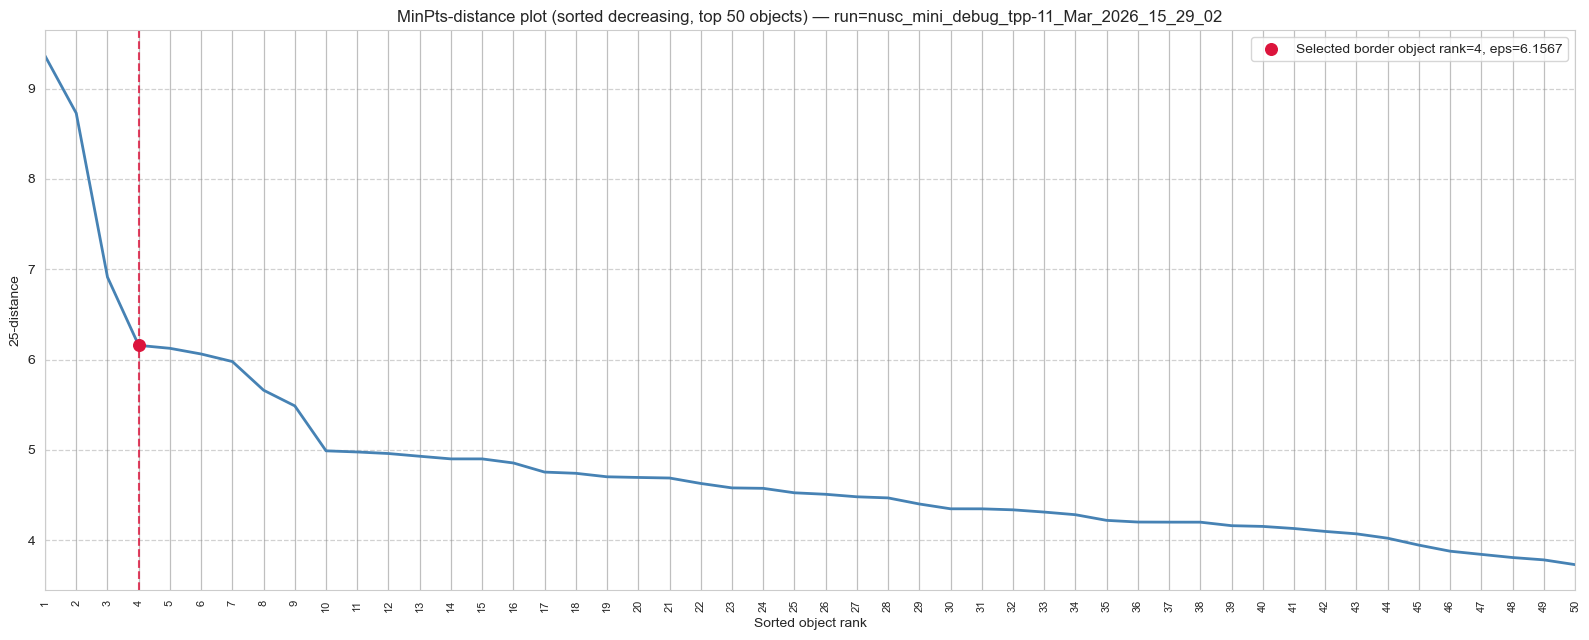

Feature dimension d: 13
Default heuristic min_samples (2 * d - 1): 25
Resolved DBSCAN min_samples: 25
Selected border object rank: 4
Selected border object row position in analysis_df: 6
Derived DBSCAN eps: 6.156693
k-distance plot saved to: ../../results/interpretable_model/dbscan_umap/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/k_distance_plot_ml_ade.png


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_features = len(feature_cols)
default_dbscan_min_samples = 2 * n_features - 1
dbscan_min_samples = RUN_SPEC['dbscan_min_samples'] or default_dbscan_min_samples
border_object_rank = int(RUN_SPEC['dbscan_border_object_rank'])

if dbscan_min_samples < 2:
    raise ValueError(f'dbscan_min_samples must be at least 2. Received {dbscan_min_samples}.')
if dbscan_min_samples > len(analysis_df):
    raise ValueError(
        'dbscan_min_samples must not exceed the number of rows. '
        f'min_samples={dbscan_min_samples}, rows={len(analysis_df)}'
    )
if not (1 <= border_object_rank <= len(analysis_df)):
    raise ValueError(
        'dbscan_border_object_rank must be between 1 and the number of clustered rows. '
        f'rank={border_object_rank}, rows={len(analysis_df)}'
    )

knn = NearestNeighbors(n_neighbors=dbscan_min_samples)
knn.fit(X_scaled)
neighbor_distances, _ = knn.kneighbors(X_scaled)

# `kneighbors` includes each row itself at distance zero, so the last column below
# is the MinPts-distance under scikit-learn's `min_samples` convention.
k_distances = neighbor_distances[:, -1]
analysis_df['k_distance_min_pts'] = k_distances

sorted_order_desc = np.argsort(k_distances)[::-1]
sorted_k_distances = k_distances[sorted_order_desc]
selected_sorted_idx = border_object_rank - 1
selected_row_idx = int(sorted_order_desc[selected_sorted_idx])
dbscan_eps = float(sorted_k_distances[selected_sorted_idx])

k_distance_plot_path = PLOTS_DIR / f'k_distance_plot_{prepared_target}.png'
plot_rank_limit = min(50, len(sorted_k_distances))
sorted_ranks = np.arange(1, len(sorted_k_distances) + 1)
display_ranks = sorted_ranks[:plot_rank_limit]
display_k_distances = sorted_k_distances[:plot_rank_limit]
major_ticks = np.arange(1, plot_rank_limit + 1)
minor_ticks = major_ticks

fig, ax = plt.subplots(figsize=(16, 6.5))
ax.plot(display_ranks, display_k_distances, color='steelblue', linewidth=2)
if border_object_rank <= plot_rank_limit:
    ax.axvline(border_object_rank, color='crimson', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.scatter(
        [border_object_rank],
        [dbscan_eps],
        color='crimson',
        s=70,
        zorder=3,
        label=f'Selected border object rank={border_object_rank}, eps={dbscan_eps:.4f}',
    )
else:
    ax.text(
        0.99,
        0.97,
        f'Selected border rank {border_object_rank} is outside the displayed top {plot_rank_limit} objects.\nDerived eps={dbscan_eps:.4f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.85, 'edgecolor': '0.7'},
    )
ax.set_title(f'MinPts-distance plot (sorted decreasing, top {plot_rank_limit} objects) — run={run_name}')
ax.set_xlabel('Sorted object rank')
ax.set_ylabel(f'{dbscan_min_samples}-distance')
ax.set_xlim(1, plot_rank_limit)
ax.set_xticks(major_ticks)
ax.set_xticks(minor_ticks, minor=True)
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelrotation=90, labelsize=8)
ax.grid(axis='x', which='major', linestyle='-', linewidth=0.9, alpha=0.45, color='0.45')
ax.grid(axis='x', which='minor', linestyle=':', linewidth=0.7, alpha=0.25, color='0.55')
ax.grid(axis='y', which='major', linestyle='--', linewidth=0.9, alpha=0.4, color='0.55')
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.savefig(k_distance_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Feature dimension d: {n_features}')
print(f'Default heuristic min_samples (2 * d - 1): {default_dbscan_min_samples}')
print(f'Resolved DBSCAN min_samples: {dbscan_min_samples}')
print(f'Selected border object rank: {border_object_rank}')
print(f'Selected border object row position in analysis_df: {selected_row_idx}')
print(f'Derived DBSCAN eps: {dbscan_eps:.6f}')
print(f'k-distance plot saved to: {k_distance_plot_path}')


## 6. Fit DBSCAN and Compute UMAP
**Purpose:** Run DBSCAN with the heuristic-derived parameters and compute one shared 2D UMAP embedding on the standardized characteristics.<br>
**Inputs:** standardized feature matrix plus the resolved `dbscan_min_samples`, derived `dbscan_eps`, and UMAP hyperparameters from `RUN_SPEC`.<br>
**Outputs:** DBSCAN cluster labels, noise indicator, 2D UMAP coordinates, and a cluster summary table attached to the analysis dataframe.<br>
**How to Verify:** confirm the printed cluster counts, total noise fraction, and that `umap_x`/`umap_y` are populated for every row.


In [21]:
dbscan = DBSCAN(
    eps=dbscan_eps,
    min_samples=dbscan_min_samples,
)
cluster_labels = dbscan.fit_predict(X_scaled)

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=RUN_SPEC['umap_n_neighbors'],
    min_dist=RUN_SPEC['umap_min_dist'],
    random_state=RUN_SPEC['random_state'],
)
embedding = umap_model.fit_transform(X_scaled)

analysis_df['dbscan_cluster'] = cluster_labels
analysis_df['is_noise'] = analysis_df['dbscan_cluster'] == -1
analysis_df['umap_x'] = embedding[:, 0]
analysis_df['umap_y'] = embedding[:, 1]

cluster_summary_df = (
    analysis_df['dbscan_cluster']
    .value_counts(dropna=False)
    .rename_axis('dbscan_cluster')
    .reset_index(name='count')
    .sort_values('dbscan_cluster')
    .reset_index(drop=True)
)
cluster_summary_df['fraction'] = cluster_summary_df['count'] / len(analysis_df)

n_noise = int(analysis_df['is_noise'].sum())
noise_fraction = n_noise / len(analysis_df)
n_clusters = analysis_df.loc[~analysis_df['is_noise'], 'dbscan_cluster'].nunique()

print(f'Total trajectories clustered: {len(analysis_df)}')
print(f'Resolved DBSCAN parameters: eps={dbscan_eps:.6f}, min_samples={dbscan_min_samples}')
print(f'Number of DBSCAN clusters (excluding noise): {n_clusters}')
print(f'Noise trajectories: {n_noise} ({noise_fraction:.2%})')
display(cluster_summary_df)


Total trajectories clustered: 451
Resolved DBSCAN parameters: eps=6.156693, min_samples=25
Number of DBSCAN clusters (excluding noise): 1
Noise trajectories: 0 (0.00%)


,dbscan_cluster,count,fraction
0,0,451,1.0


## 7. Visualize the Embedding
**Purpose:** Show the shared 2D UMAP embedding once by discrete DBSCAN clusters and once by continuous trajectory performance metrics.<br>
**Inputs:** enriched analysis dataframe with UMAP coordinates, cluster labels, and selected metric columns.<br>
**Outputs:** saved cluster-colored and metric-colored UMAP figures under the run-scoped results directory.<br>
**How to Verify:** the cluster plot should highlight noise distinctly and every metric panel should reuse the same `umap_x`/`umap_y` positions.


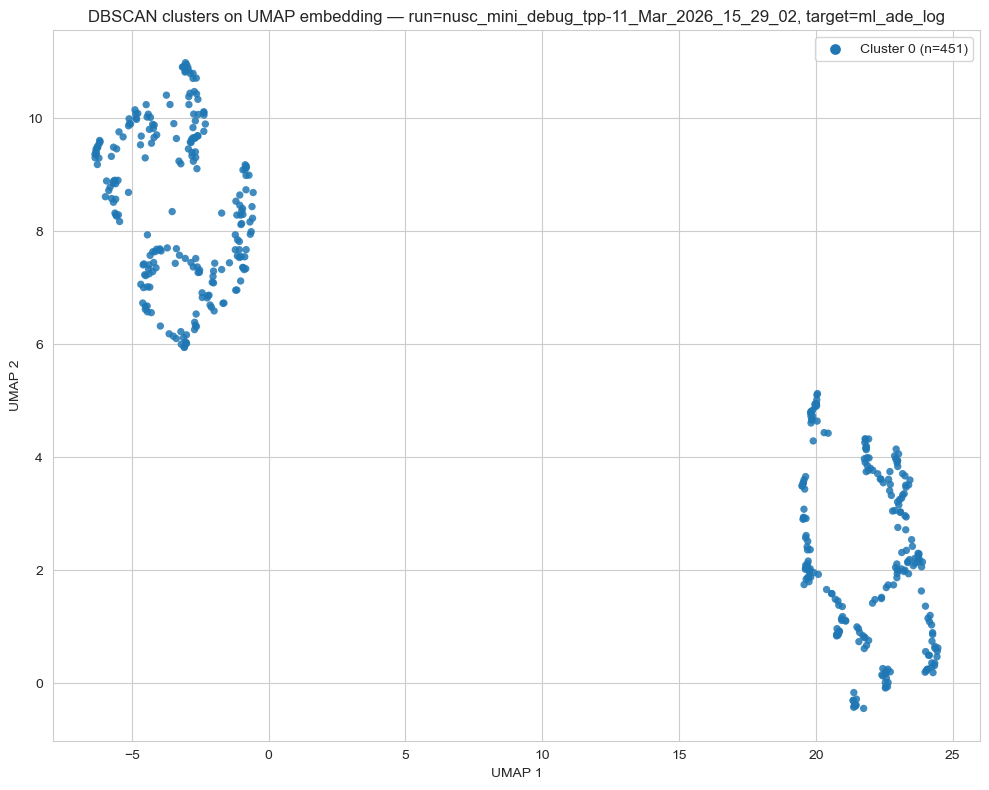

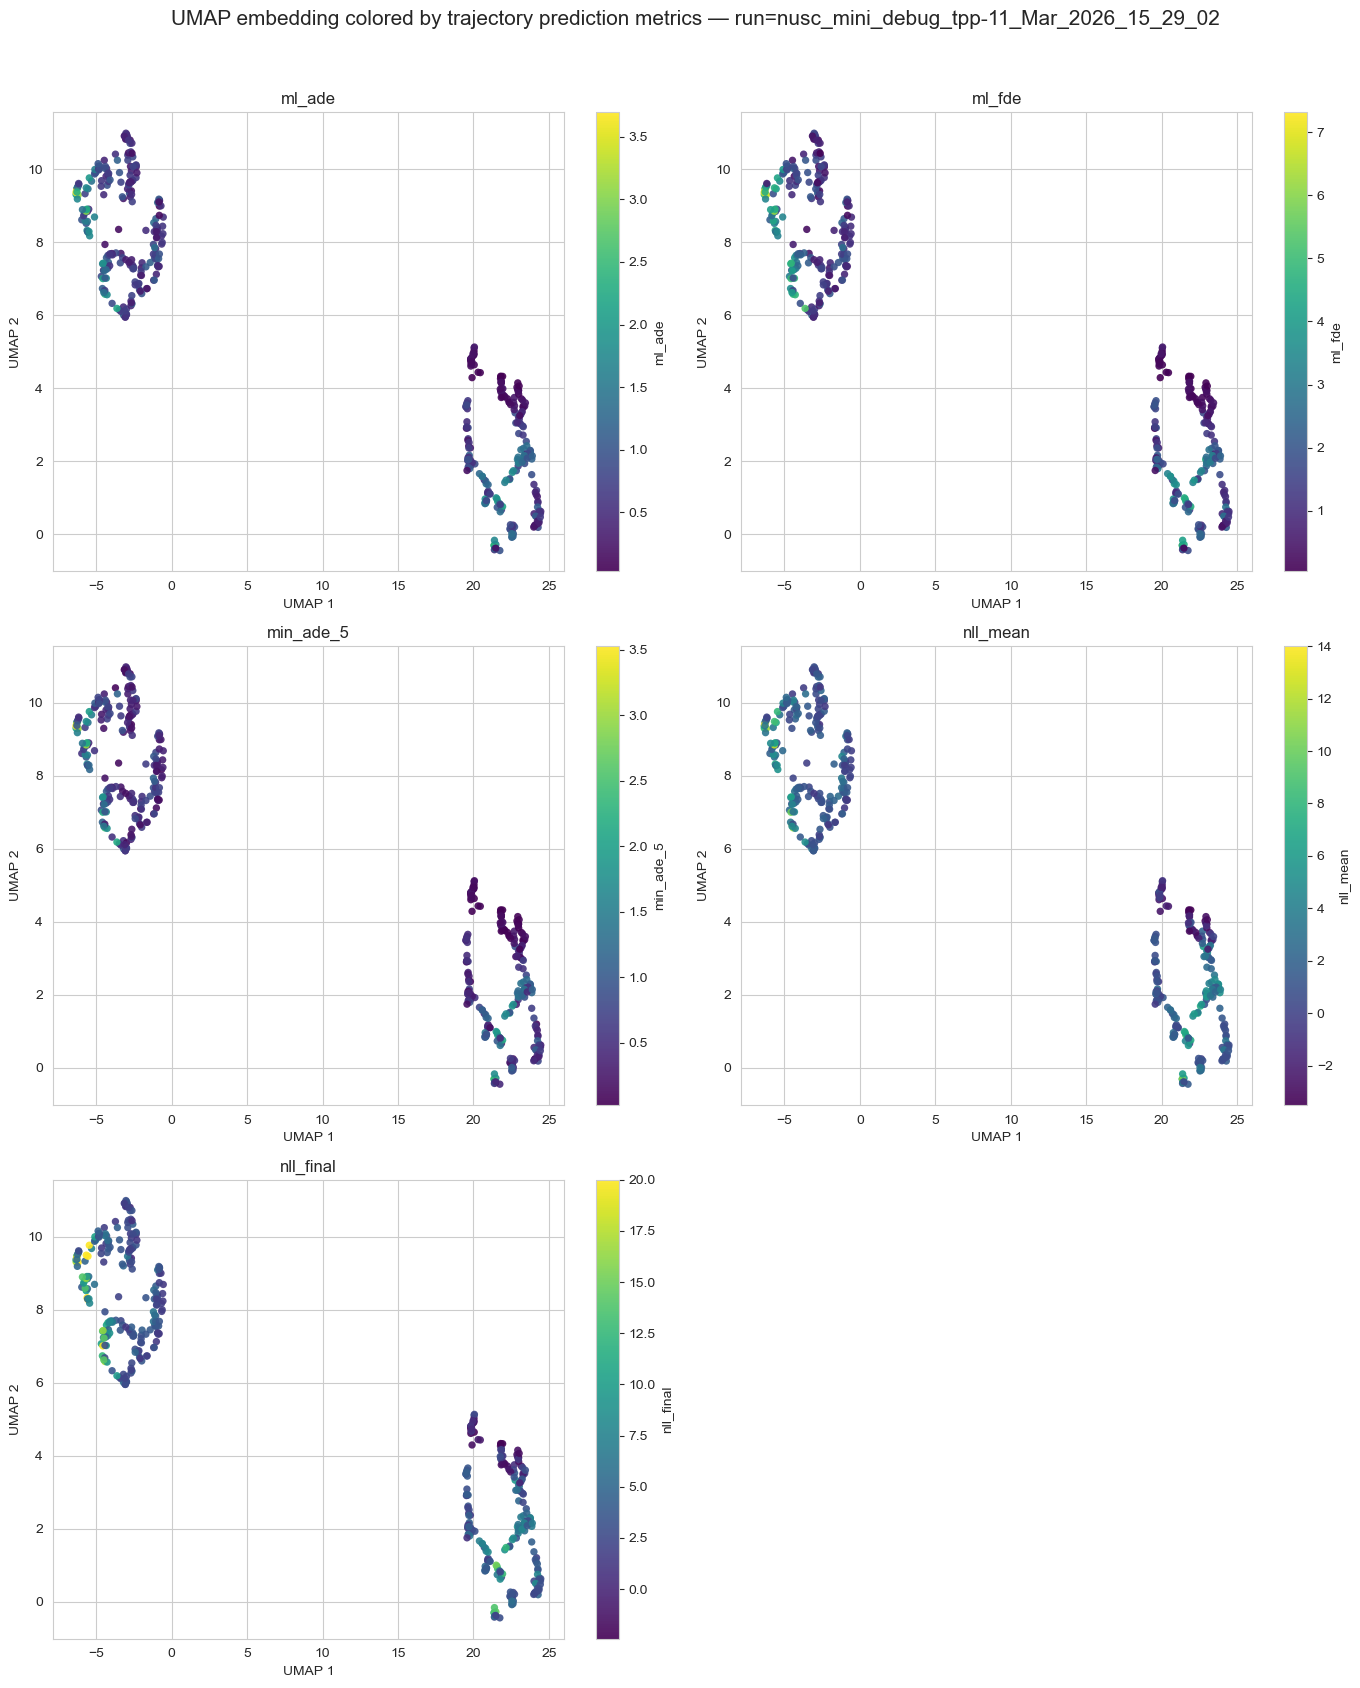

Cluster-colored UMAP saved to: ../../results/interpretable_model/dbscan_umap/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/umap_clusters_ml_ade.png
Metric-colored UMAP saved to:  ../../results/interpretable_model/dbscan_umap/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/umap_metrics_ml_ade.png


In [22]:
cluster_plot_path = PLOTS_DIR / f'umap_clusters_{prepared_target}.png'

non_noise_clusters = sorted(cluster for cluster in analysis_df['dbscan_cluster'].unique() if cluster != -1)
cluster_palette = sns.color_palette('tab20', n_colors=max(len(non_noise_clusters), 1))
cluster_color_lookup = {cluster: cluster_palette[idx % len(cluster_palette)] for idx, cluster in enumerate(non_noise_clusters)}
cluster_color_lookup[-1] = (0.65, 0.65, 0.65)
point_colors = analysis_df['dbscan_cluster'].map(cluster_color_lookup)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(
    analysis_df['umap_x'],
    analysis_df['umap_y'],
    c=point_colors.tolist(),
    s=28,
    alpha=0.85,
    edgecolors='none',
)

for cluster in non_noise_clusters:
    cluster_rows = analysis_df.loc[analysis_df['dbscan_cluster'] == cluster]
    ax.scatter([], [], c=[cluster_color_lookup[cluster]], s=45, label=f'Cluster {cluster} (n={len(cluster_rows)})')

if (-1 in analysis_df['dbscan_cluster'].values):
    ax.scatter([], [], c=[cluster_color_lookup[-1]], s=45, label=f'Noise (n={n_noise})')

ax.set_title(f'DBSCAN clusters on UMAP embedding — run={run_name}, target={target_col}')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.savefig(cluster_plot_path, dpi=150, bbox_inches='tight')
plt.show()

metric_plot_path = PLOTS_DIR / f'umap_metrics_{prepared_target}.png'
n_metrics = len(metric_cols_present)
n_cols = 2 if n_metrics > 1 else 1
n_rows = int(np.ceil(n_metrics / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5.5 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for ax, metric_col in zip(axes_flat, metric_cols_present):
    scatter = ax.scatter(
        analysis_df['umap_x'],
        analysis_df['umap_y'],
        c=analysis_df[metric_col],
        cmap='viridis',
        s=28,
        alpha=0.9,
        edgecolors='none',
    )
    ax.set_title(metric_col)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label(metric_col)

for ax in axes_flat[n_metrics:]:
    ax.set_visible(False)

fig.suptitle(f'UMAP embedding colored by trajectory prediction metrics — run={run_name}', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(metric_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Cluster-colored UMAP saved to: {cluster_plot_path}')
print(f'Metric-colored UMAP saved to:  {metric_plot_path}')


## 8. Export Enriched Analysis Table
**Purpose:** Persist the prepared features, selected metric columns, MinPts-distance values, DBSCAN labels, noise flag, and UMAP coordinates for later inspection.<br>
**Inputs:** merged and enriched analysis dataframe.<br>
**Outputs:** one run-scoped CSV plus a concise artifact summary.<br>
**How to Verify:** confirm the exported CSV path exists and contains the feature columns, `k_distance_min_pts`, `dbscan_cluster`, `is_noise`, `umap_x`, and `umap_y`.


In [23]:
export_path = TABLES_DIR / f'clustered_umap_data_{prepared_target}.csv'
analysis_df.to_csv(export_path, index=False)

print('Saved artifacts:')
print(f'- Exported analysis table: {export_path}')
print(f'- Cluster summary rows:    {len(cluster_summary_df)}')
print(f'- k-distance plot:         {k_distance_plot_path}')
print(f'- Cluster UMAP plot:       {cluster_plot_path}')
print(f'- Metric UMAP plot:        {metric_plot_path}')
print(f'- Metrics rendered:        {metric_cols_present}')
print(f'- DBSCAN min_samples:      {dbscan_min_samples}')
print(f'- DBSCAN eps:              {dbscan_eps:.6f}')


Saved artifacts:
- Exported analysis table: ../../results/interpretable_model/dbscan_umap/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/clustered_umap_data_ml_ade.csv
- Cluster summary rows:    1
- k-distance plot:         ../../results/interpretable_model/dbscan_umap/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/k_distance_plot_ml_ade.png
- Cluster UMAP plot:       ../../results/interpretable_model/dbscan_umap/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/umap_clusters_ml_ade.png
- Metric UMAP plot:        ../../results/interpretable_model/dbscan_umap/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/plots/umap_metrics_ml_ade.png
- Metrics rendered:        ['ml_ade', 'ml_fde', 'min_ade_5', 'nll_mean', 'nll_final']
- DBSCAN min_samples:      25
- DBSCAN eps:              6.156693
